In [6]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [7]:
FILE_PATH = "Данные_для_курсовои_Классическое_МО.xlsx"
TARGET = "CC50, mM"
ID_COL = "Unnamed: 0"
RANDOM_STATE = 42

df = pd.read_excel(FILE_PATH)

print("Исходная размерность датасета:", df.shape)
display(df.head())

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])

print("Размерность после удаления индексного столбца:", df.shape)

Исходная размерность датасета: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


Размерность после удаления индексного столбца: (1001, 213)


Размерность X: (1001, 210)
Размерность y: (1001,)

Статистика по CC50, mM:


count    1001.000000
mean      589.110728
std       642.867508
min         0.700808
25%        99.999036
50%       411.039342
75%       894.089176
max      4538.976189
Name: CC50, mM, dtype: float64

Медиана CC50, mM: 411.039342


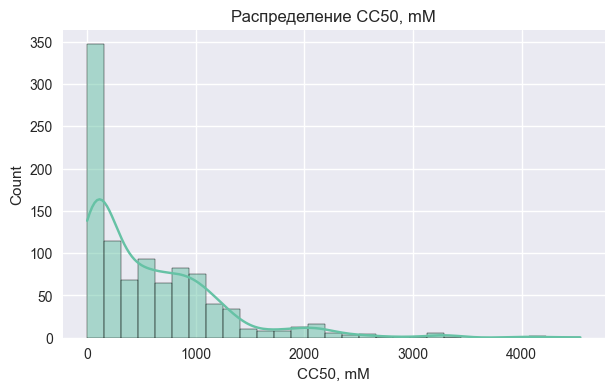

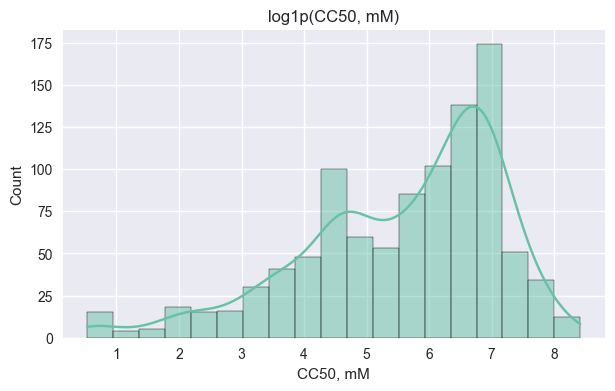

In [8]:
# 2. Подготовка данных


X = df.drop(columns=["IC50, mM", "CC50, mM", "SI"])
y = df[TARGET].copy()

print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

print(f"\nСтатистика по {TARGET}:")
display(y.describe())

print(f"Медиана {TARGET}: {y.median():.6f}")

plt.figure(figsize=(7, 4))
sns.histplot(y, kde=True)
plt.title(f"Распределение {TARGET}")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(y), kde=True)
plt.title(f"log1p({TARGET})")
plt.show()



Вывод: CC50 имеет асимметричное распределение, поэтому для регрессии применяем log1p-преобразование целевой переменной.

In [9]:
# 3. Разделение на train/test


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)

Train X: (800, 210)
Test X: (201, 210)
Train y: (800,)
Test y: (201,)


In [10]:
# 4. Вспомогательные функции и модели


def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred)
    }

def build_ridge():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

def build_rf():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

def build_et():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

def build_gbr():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

models = {
    "Ridge": build_ridge(),
    "RandomForest": build_rf(),
    "ExtraTrees": build_et(),
    "GradientBoosting": build_gbr()
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [11]:
# 5. Базовые модели (5-fold CV)


baseline_results = []

for name, model in models.items():
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({
        "Model": name,
        "CV_MAE_mean": -scores["test_mae"].mean(),
        "CV_MAE_std": scores["test_mae"].std(),
        "CV_RMSE_mean": -scores["test_rmse"].mean(),
        "CV_R2_mean": scores["test_r2"].mean()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("CV_MAE_mean")
print("Базовые модели (5-fold CV):")
display(baseline_df)

Базовые модели (5-fold CV):


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean
2,ExtraTrees,2.873214e+02,3.263025e+01,4.704911e+02,4.206986e-01
1,RandomForest,3.054107e+02,3.460810e+01,4.832092e+02,3.885474e-01
3,GradientBoosting,3.114369e+02,3.310014e+01,4.907975e+02,3.685063e-01
0,Ridge,3.157196e+43,6.314392e+43,3.993572e+44,-2.960508e+84


In [12]:
# 6. Подбор гиперпараметров


search_spaces = {
    "Ridge": {
        "regressor__model__alpha": np.logspace(-3, 3, 100)
    },
    "RandomForest": {
        "regressor__model__n_estimators": [200, 300, 500, 700],
        "regressor__model__max_depth": [None, 5, 10, 15, 20, 30],
        "regressor__model__min_samples_split": [2, 5, 10],
        "regressor__model__min_samples_leaf": [1, 2, 4],
        "regressor__model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "ExtraTrees": {
        "regressor__model__n_estimators": [200, 300, 500, 700],
        "regressor__model__max_depth": [None, 5, 10, 15, 20, 30],
        "regressor__model__min_samples_split": [2, 5, 10],
        "regressor__model__min_samples_leaf": [1, 2, 4],
        "regressor__model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "GradientBoosting": {
        "regressor__model__n_estimators": [100, 200, 300, 500],
        "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "regressor__model__max_depth": [2, 3, 4, 5],
        "regressor__model__subsample": [0.7, 0.8, 1.0],
        "regressor__model__min_samples_split": [2, 5, 10]
    }
}

best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nПодбор гиперпараметров для {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[name],
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best_CV_MAE": -search.best_score_,
        "Best_Params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("Best_CV_MAE")
print("\nРезультаты после подбора гиперпараметров:")
display(tuning_df)


Подбор гиперпараметров для Ridge...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для RandomForest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для ExtraTrees...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для GradientBoosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Результаты после подбора гиперпараметров:


,Model,Best_CV_MAE,Best_Params
2,ExtraTrees,2.926372e+02,"{'regressor__model__n_estimators': 300, 'regre..."
3,GradientBoosting,2.949952e+02,"{'regressor__model__subsample': 0.8, 'regresso..."
1,RandomForest,3.101359e+02,"{'regressor__model__n_estimators': 300, 'regre..."
0,Ridge,1.444404e+21,{'regressor__model__alpha': 284.8035868435805}


In [13]:
# 7. Оценка на тестовой выборке


test_results = []

for name, model in best_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics = regression_metrics(y_test, preds)
    metrics["Model"] = name
    test_results.append(metrics)

test_df = pd.DataFrame(test_results).sort_values("MAE")
print("Результаты на test:")
display(test_df)

best_model_name = test_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print(f"\nЛучшая модель по MAE: {best_model_name}")

Результаты на test:


,MAE,RMSE,R2,Model
2,277.928348,492.136206,0.532842,ExtraTrees
3,284.085810,503.170066,0.511660,GradientBoosting
1,298.699162,516.085775,0.486268,RandomForest
0,390.336806,666.130029,0.144124,Ridge



Лучшая модель по MAE: ExtraTrees


In [14]:
#8. Анализ важности признаков


best_model.fit(X_train, y_train)

best_regressor = best_model.regressor_
selected_features = X_train.columns[best_regressor.named_steps["variance"].get_support()]
final_model = best_regressor.named_steps["model"]

if hasattr(final_model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)
elif hasattr(final_model, "coef_"):
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": np.abs(final_model.coef_)
    }).sort_values("importance", ascending=False)
else:
    fi = None

if fi is not None:
    print("Топ-20 наиболее важных признаков:")
    display(fi.head(20))
else:
    print("Для данной модели важность признаков не извлекается напрямую.")

Топ-20 наиболее важных признаков:


,feature,importance
139,fr_NH2,0.033132
18,BCUT2D_MWLOW,0.022477
146,fr_allylic_oxid,0.022236
138,fr_NH1,0.021919
56,PEOE_VSA6,0.020003
44,Kappa3,0.019798
104,NHOHCount,0.019775
132,fr_C_O,0.017817
57,PEOE_VSA7,0.017548
43,Kappa2,0.014868


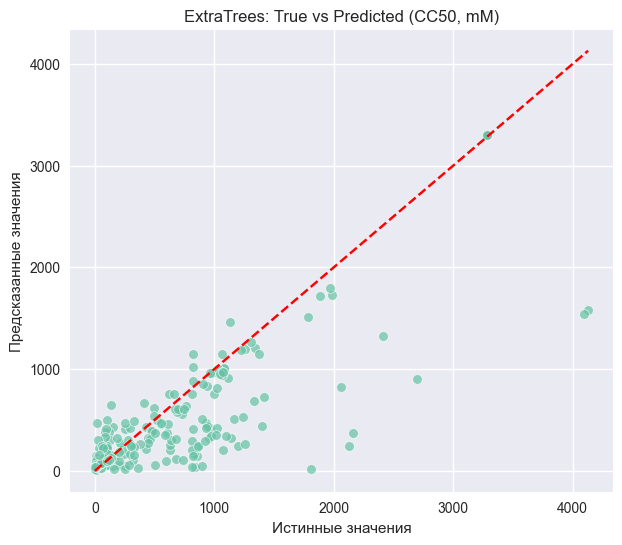

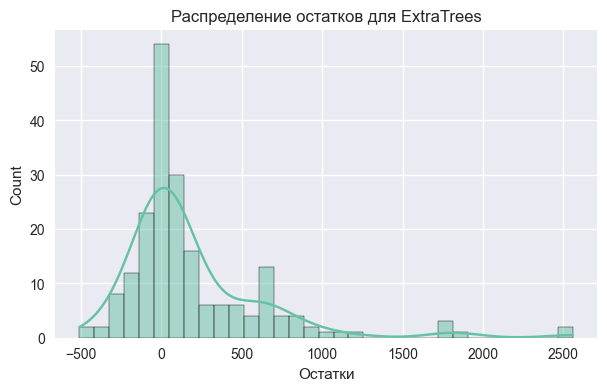

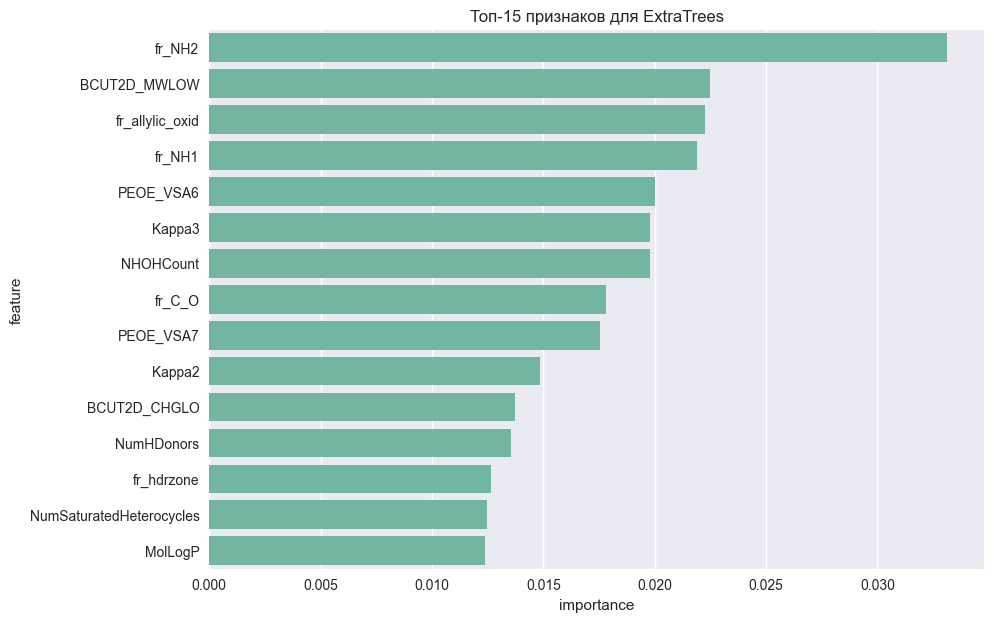

In [15]:
# 9. Визуализация результатов


best_preds = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title(f"{best_model_name}: True vs Predicted ({TARGET})")
plt.show()

residuals = y_test - best_preds

plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True)
plt.title(f"Распределение остатков для {best_model_name}")
plt.xlabel("Остатки")
plt.show()

if fi is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi.head(15), x="importance", y="feature")
    plt.title(f"Топ-15 признаков для {best_model_name}")
    plt.show()

ИТОГОВЫЕ ВЫВОДЫ ПО REGRESSION: CC50
1. Для задачи регрессии CC50 были сравнены 4 модели:
   - Ridge
   - RandomForest
   - ExtraTrees
   - GradientBoosting

2. Для целевой переменной применено log1p-преобразование, так как распределение асимметрично.

3. Основной критерий выбора модели:
   - MAE (главный)
   - RMSE
   - R2
4. Для химических дескрипторов обычно более сильными оказываются нелинейные ансамбли,
   поскольку они лучше улавливают сложные зависимости между признаками и токсичностью.

5. Итоговое решение выбрано на основании:
   - устойчивости на 5-fold cross-validation
   - качества на test
   - интерпретируемости через feature importance